# DGL API Tutorial: Graph Neural Networks for Recommendation Systems

## Overview

This tutorial demonstrates how to use **Deep Graph Library (DGL)** to build a graph neural network-based movie recommendation system. We treat recommendation as a **link prediction** problem on a bipartite graph, where users and movies are nodes, and ratings form edges.

### What is DGL?

**DGL (Deep Graph Library)** is a Python library designed for deep learning on graphs. It provides:
- Efficient graph data structures (homogeneous and heterogeneous graphs)
- Built-in graph neural network layers (GCN, GraphSAGE, GAT, etc.)
- Message passing frameworks for learning node/edge representations
- Seamless integration with PyTorch and TensorFlow

### Native DGL API vs Wrapper Layer

This tutorial demonstrates two levels of abstraction:

1. **Native DGL API**: Core DGL functions like `dgl.heterograph()`, `dgl.nn.SAGEConv()`, `g.ndata`, `g.edata`
   - Direct control over graph construction and model architecture
   - Understanding of underlying graph operations
   - Essential for custom implementations

2. **Wrapper Layer** (`dgl_utils.py`): Convenience functions built on top of native DGL
   - Simplifies common workflows (data loading, graph construction, training)
   - Reduces boilerplate code
   - Makes the tutorial more accessible

### Learning Objectives

By the end of this tutorial, you will:
- Understand how to construct heterogeneous graphs in DGL
- Learn to attach node and edge features to graphs
- Implement GraphSAGE for link prediction
- Evaluate recommendation systems using Precision@K, Recall@K, and RMSE
- Generate personalized top-N recommendations
- Compare GNN-based approaches with traditional baselines

### Problem Formulation

We model movie recommendation as a **link prediction** task:
- **Nodes**: Users and Movies (two node types → heterogeneous graph)
- **Edges**: User-movie ratings (with edge weights representing rating values)
- **Goal**: Predict missing user-movie interactions (links) to recommend unseen movies

This approach leverages both:
- **Graph structure**: Who rated what (collaborative filtering signal)
- **Node features**: Movie genres, user preferences (content-based signal)

### Architecture Overview


![GraphSAGE Architecture](images/img1.png)


## 1. Environment Setup

### Package Installation

We need several key packages:
- **PyTorch**: Deep learning framework (DGL is built on PyTorch)
- **DGL**: Deep Graph Library for graph neural networks
- **Pandas/NumPy**: Data manipulation and numerical operations
- **Scikit-learn**: Machine learning utilities (for baselines and metrics)
- **Matplotlib**: Visualization

**Note**: DGL requires a specific installation method due to its dependencies on PyTorch and CUDA versions. We install it from DGL's official wheel repository.


### Imports and Configuration

**Key imports:**
- `dgl`: Core DGL library for graph operations
- `dgl.nn`: DGL's neural network layers (GraphSAGE, GCN, etc.)
- `torch`: PyTorch for tensor operations and neural networks
- `pandas`: Data manipulation (loading CSV files)
- `dgl_utils`: Our wrapper layer for convenience functions

**Jupyter magic commands:**
- `%load_ext autoreload`: Enables automatic module reloading
- `%autoreload 2`: Reloads modules before executing code (useful during development)
- `%matplotlib inline`: Displays plots inline in the notebook

**Reproducibility**: We set random seeds for NumPy, Python's random module, and PyTorch to ensure reproducible results.


In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
import logging
import random
import numpy as np
import pandas as pd
import torch
import dgl
import dgl.nn as dglnn

import dgl_utils as du

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')
logger = logging.getLogger("DGL_API")

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Verify versions
print(f"PyTorch version: {torch.__version__}")
print(f"DGL version: {dgl.__version__}")
print(f"Device: {'CUDA' if torch.cuda.is_available() else 'CPU'}")


PyTorch version: 2.0.1+cu117
DGL version: 1.1.2
Device: CPU


## 2. Understanding the Problem: Bipartite Graphs for Recommendations

### Why Bipartite Graphs?

A **bipartite graph** is a graph where nodes can be divided into two disjoint sets such that edges only connect nodes from different sets. This perfectly models recommendation systems:

- **Set 1**: Users
- **Set 2**: Movies (or items)
- **Edges**: Ratings/interactions (only between users and movies, never user-user or movie-movie)

### MovieLens Dataset

The MovieLens dataset contains:
- **Ratings**: User-movie interactions with ratings (1-5 stars) and timestamps
- **Movies**: Movie metadata including titles and genres
- **Structure**: Each row in ratings.csv represents an edge: `(userId, movieId, rating, timestamp)`

### Graph Representation Benefits

Using graphs for recommendations allows us to:
1. **Capture collaborative signals**: Users with similar rating patterns are implicitly connected through shared movies
2. **Leverage graph structure**: GNNs can learn from multi-hop neighborhoods (e.g., "users who liked movies similar to movies you liked")
3. **Incorporate side information**: Node features (genres) and edge features (ratings) can be naturally integrated


### Data Setup

**Before running this notebook**, ensure you have the MovieLens 20M dataset files (`rating.csv` and `movie.csv`) in the `data/raw/` directory. 

**Note**: If data files are missing, the notebook will automatically use a toy dataset, so you can still run the tutorial.


**Validate your data** (optional but recommended):
```bash 
python -c "from validate_data import validate_movielens_data; validate_movielens_data('data/raw')"
```

For detailed download and setup instructions, see the main `README.md`.


### Data Loading: Native Pandas Operations

First, let's see how to load data using standard pandas operations. This demonstrates the raw data structure before we convert it to a graph.


In [ ]:
# Configure data paths
DATA_DIR = "data/raw"
RATINGS_CSV = os.path.join(DATA_DIR, "rating.csv")
MOVIES_CSV = os.path.join(DATA_DIR, "movie.csv")

USE_REAL = os.path.exists(RATINGS_CSV) and os.path.exists(MOVIES_CSV)

if USE_REAL:
    movies_df = pd.read_csv(MOVIES_CSV)
    ratings_df = pd.read_csv(RATINGS_CSV)
    print(f"Loaded real MovieLens data: {len(ratings_df)} ratings, {len(movies_df)} movies")
    
    MAX_RATINGS = 200_000   
    if len(ratings_df) > MAX_RATINGS:
        ratings_df = ratings_df.sample(
            n=MAX_RATINGS,
            random_state=SEED
        ).reset_index(drop=True)
        print(f"Subsampled to {len(ratings_df)} ratings")

    
    used_movie_ids = ratings_df["movieId"].unique()
    movies_df = movies_df[movies_df["movieId"].isin(used_movie_ids)].reset_index(drop=True)
else:
    # Use dummy data from our utility functions
    print("Real data not found, using dummy dataset")
    movies_df, ratings_df = du.load_dummy_data()

# Display data structure
print("\n--- Movie Data Sample ---")
print(movies_df.head())
print(f"\nMovie columns: {list(movies_df.columns)}")
print(f"\n--- Rating Data Sample ---")
print(ratings_df.head())
print(f"\nRating columns: {list(ratings_df.columns)}")
print(f"\nUnique users: {ratings_df['userId'].nunique()}")
print(f"Unique movies: {ratings_df['movieId'].nunique()}")
print(f"Total ratings: {len(ratings_df)}")


Loaded real MovieLens data: 20000263 ratings, 27278 movies
Subsampled to 200000 ratings

--- Movie Data Sample ---
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  

Movie columns: ['movieId', 'title', 'genres']

--- Rating Data Sample ---
   userId  movieId  rating            timestamp
0  122270     8360     3.5  2012-04-22 01:07:04
1   49018       32     2.0  2001-09-11 07:50:36
2   89527   109374     3.5  2015-01-06 09:26:40
3  106704     1060     

In [34]:
# Data inspection: Understanding the dataset structure
print("=" * 60)
print("DATASET INSPECTION")
print("=" * 60)

print(f"\n--- Ratings Data ---")
print(f"Total ratings: {len(ratings_df):,}")
print(f"Unique users: {ratings_df['userId'].nunique():,}")
print(f"Unique movies: {ratings_df['movieId'].nunique():,}")
print(f"Date range: {ratings_df['timestamp'].min() if 'timestamp' in ratings_df.columns else 'N/A'} to {ratings_df['timestamp'].max() if 'timestamp' in ratings_df.columns else 'N/A'}")

# Rating distribution
if 'rating' in ratings_df.columns:
    print(f"\nRating distribution:")
    print(ratings_df['rating'].value_counts().sort_index())
    print(f"Mean rating: {ratings_df['rating'].mean():.2f}")
    print(f"Std rating: {ratings_df['rating'].std():.2f}")

print(f"\n--- Movies Data ---")
print(f"Total movies: {len(movies_df):,}")
if 'genres' in movies_df.columns:
    # Count movies per genre
    all_genres = set()
    for genres_str in movies_df['genres'].dropna():
        all_genres.update(genres_str.split('|'))
    print(f"Unique genres: {len(all_genres)}")
    print(f"Sample genres: {list(all_genres)[:10]}")

# Check for missing values
print(f"\n--- Data Quality ---")
print(f"Ratings missing values:")
print(ratings_df.isnull().sum())
print(f"\nMovies missing values:")
print(movies_df.isnull().sum())

print("\n" + "=" * 60)

DATASET INSPECTION

--- Ratings Data ---
Total ratings: 200,000
Unique users: 75,393
Unique movies: 10,332
Date range: 1996-01-29 00:00:00 to 2015-03-31 05:41:57

Rating distribution:
rating
0.5     2343
1.0     6667
1.5     2771
2.0    14598
2.5     8810
3.0    42828
3.5    21873
4.0    55632
4.5    15399
5.0    29079
Name: count, dtype: int64
Mean rating: 3.53
Std rating: 1.05

--- Movies Data ---
Total movies: 10,332
Unique genres: 20
Sample genres: ['Film-Noir', 'Crime', 'Documentary', 'Action', 'Adventure', 'Drama', 'IMAX', 'Children', 'Musical', 'Horror']

--- Data Quality ---
Ratings missing values:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Movies missing values:
movieId    0
title      0
genres     0
dtype: int64



## 3. Graph Construction: Native DGL API

### Understanding `dgl.heterograph()`

DGL's `heterograph()` function creates a **heterogeneous graph** with multiple node types and edge types. The function signature is:

```python
dgl.heterograph(data_dict, num_nodes_dict=None)
```

Where `data_dict` maps edge types (tuples) to edge lists:
- Edge type format: `(src_node_type, edge_type, dst_node_type)`
- Edge list: `(source_nodes, destination_nodes)` as tensors

### Why Heterogeneous Graphs?

In our recommendation system:
- **Node types**: `user` and `movie` (different types with different properties)
- **Edge types**: `rates` (user → movie) and `rated_by` (movie → user, reverse direction)
- **Benefits**: Allows type-specific operations and features

Let's first see how to construct a small graph using the native API:


In [35]:
# Example: Native DGL API for graph construction
# Let's create a tiny example graph manually to understand the API

# Sample data: 3 users, 4 movies, 5 ratings
sample_ratings = pd.DataFrame({
    'userId': [0, 0, 1, 1, 2],
    'movieId': [0, 1, 1, 2, 3],
    'rating': [5.0, 4.0, 3.5, 4.5, 5.0]
})

# Step 1: Create mappings (raw IDs to contiguous indices)
# This is necessary because DGL requires 0-indexed contiguous node IDs
user_ids = sample_ratings['userId'].unique()
movie_ids = sample_ratings['movieId'].unique()
user_map = {uid: i for i, uid in enumerate(user_ids)}
movie_map = {mid: i for i, mid in enumerate(movie_ids)}

# Step 2: Map ratings to graph indices
src_nodes = [user_map[uid] for uid in sample_ratings['userId']]
dst_nodes = [movie_map[mid] for mid in sample_ratings['movieId']]

# Step 3: Create heterogeneous graph using native DGL API
# Format: {(src_type, edge_type, dst_type): (src_tensor, dst_tensor)}
hetero_data = {
    ('user', 'rates', 'movie'): (torch.tensor(src_nodes), torch.tensor(dst_nodes)),
    ('movie', 'rated_by', 'user'): (torch.tensor(dst_nodes), torch.tensor(src_nodes))  # Reverse edges
}

# Native DGL API call
g_example = dgl.heterograph(hetero_data)

print("Example Graph (Native DGL API):")
print(g_example)
print(f"\nNode types: {g_example.ntypes}")
print(f"Edge types: {g_example.etypes}")
print(f"Canonical edge types: {g_example.canonical_etypes}")
print(f"\nNumber of users: {g_example.num_nodes('user')}")
print(f"Number of movies: {g_example.num_nodes('movie')}")
print(f"Number of edges (rates): {g_example.num_edges(('user', 'rates', 'movie'))}")


Example Graph (Native DGL API):
Graph(num_nodes={'movie': 4, 'user': 3},
      num_edges={('movie', 'rated_by', 'user'): 5, ('user', 'rates', 'movie'): 5},
      metagraph=[('movie', 'user', 'rated_by'), ('user', 'movie', 'rates')])

Node types: ['movie', 'user']
Edge types: ['rated_by', 'rates']
Canonical edge types: [('movie', 'rated_by', 'user'), ('user', 'rates', 'movie')]

Number of users: 3
Number of movies: 4
Number of edges (rates): 5


### Using Our Wrapper for Convenience

While the native API gives us full control, it requires manual data cleaning, ID remapping, and edge construction. Our wrapper function `create_hetero_graph_from_pandas()` automates these steps:

1. **Data cleaning**: Handles missing values
2. **ID remapping**: Creates contiguous 0-indexed mappings automatically
3. **Graph construction**: Builds both forward and reverse edges
4. **Returns**: Graph object and ID mappings for later use


In [36]:
# Build the full graph using our wrapper function
g, id_maps = du.create_hetero_graph_from_pandas(ratings_df, movies_df)

print("Full Graph Structure:")
print(g)
print(f"\n--- ID Mappings (Raw IDs → Graph Indices) ---")
print(f"User map sample (first 5): {dict(list(id_maps['user'].items())[:5])}")
print(f"Movie map sample (first 5): {dict(list(id_maps['movie'].items())[:5])}")
print(f"\nTotal users: {g.num_nodes('user')}")
print(f"Total movies: {g.num_nodes('movie')}")
print(f"Total edges: {g.num_edges(('user', 'rates', 'movie'))}")


2025-12-04 12:13:06,076 - dgl_utils - INFO - Creating heterogeneous graph...
2025-12-04 12:13:06,272 - dgl_utils - INFO - Graph created: n_user=75393 n_movie=10332 n_edges=200000


Full Graph Structure:
Graph(num_nodes={'movie': 10332, 'user': 75393},
      num_edges={('movie', 'rated_by', 'user'): 200000, ('user', 'rates', 'movie'): 200000},
      metagraph=[('movie', 'user', 'rated_by'), ('user', 'movie', 'rates')])

--- ID Mappings (Raw IDs → Graph Indices) ---
User map sample (first 5): {122270: 0, 49018: 1, 89527: 2, 106704: 3, 47791: 4}
Movie map sample (first 5): {8360: 0, 32: 1, 109374: 2, 1060: 3, 1732: 4}

Total users: 75393
Total movies: 10332
Total edges: 200000


### Understanding Graph Structure

DGL graphs have several important properties:
- **Metagraph**: Describes the schema (which node types connect via which edge types)
- **Node types**: Different types of nodes (e.g., `user`, `movie`)
- **Edge types**: Different types of relationships (e.g., `rates`, `rated_by`)
- **Bidirectional edges**: We create both `(user, rates, movie)` and `(movie, rated_by, user)` to allow message passing in both directions


### Visualizing Graph Structure

Let's visualize a small subgraph to understand the structure better. This helps us see the bipartite nature and connectivity patterns.


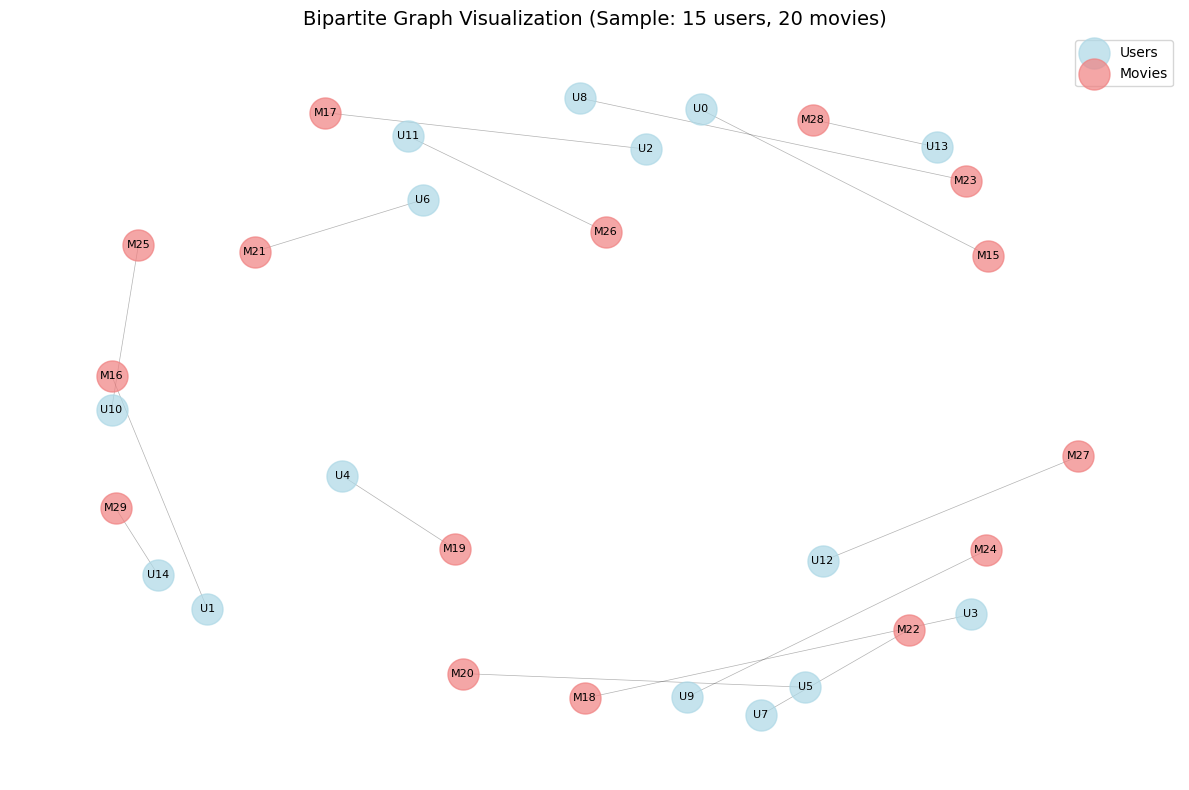

Visualized subgraph: 15 users, 15 movies, 15 edges


In [37]:
# Visualize a small subgraph using NetworkX
import networkx as nx
import matplotlib.pyplot as plt

# Extracting a small subgraph for visualization (first 20 users, first 30 movies)
def dgl_to_networkx_subgraph(g, num_users=20, num_movies=30):
    """Convert a small portion of DGL graph to NetworkX for visualization."""
    G = nx.Graph()
    
    u, v = g.edges(etype=('user', 'rates', 'movie'))
    u_list = u.tolist()
    v_list = v.tolist()
    
    edges_to_show = []
    for i in range(min(100, len(u_list))):  
        if u_list[i] < num_users and v_list[i] < num_movies:
            edges_to_show.append((u_list[i], v_list[i] + num_users))  
    
    for u_idx, m_idx in edges_to_show[:50]:  
        G.add_edge(f"U{u_idx}", f"M{m_idx}", weight=1)
    
    return G

# Create visualization
try:
    G_viz = dgl_to_networkx_subgraph(g, num_users=15, num_movies=20)

    pos = nx.spring_layout(G_viz, k=1, iterations=50, seed=SEED)

    user_nodes = [n for n in G_viz.nodes() if n.startswith('U')]
    movie_nodes = [n for n in G_viz.nodes() if n.startswith('M')]

    plt.figure(figsize=(12, 8))
    nx.draw_networkx_nodes(G_viz, pos, nodelist=user_nodes, 
                          node_color='lightblue', node_size=500, 
                          label='Users', alpha=0.7)
    nx.draw_networkx_nodes(G_viz, pos, nodelist=movie_nodes, 
                          node_color='lightcoral', node_size=500, 
                          label='Movies', alpha=0.7)
    nx.draw_networkx_edges(G_viz, pos, alpha=0.3, width=0.5)
    nx.draw_networkx_labels(G_viz, pos, font_size=8)
    
    plt.title("Bipartite Graph Visualization (Sample: 15 users, 20 movies)", fontsize=14)
    plt.legend()
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    
    print(f"Visualized subgraph: {len(user_nodes)} users, {len(movie_nodes)} movies, {G_viz.number_of_edges()} edges")
except Exception as e:
    print(f"Visualization note: {e}")
    print("(This is expected for very large graphs. The full graph has", 
          f"{g.num_nodes('user')} users and {g.num_nodes('movie')} movies)")


In [38]:
# Inspect graph properties
print("--- Graph Schema (Metagraph) ---")
print(f"Node types: {g.ntypes}")
print(f"Edge types: {g.etypes}")
print(f"Canonical edge types: {g.canonical_etypes}")

# Get detailed summary
summary = du.get_graph_summary(g)
print("\n--- Detailed Graph Summary ---")
print(summary)


--- Graph Schema (Metagraph) ---
Node types: ['movie', 'user']
Edge types: ['rated_by', 'rates']
Canonical edge types: [('movie', 'rated_by', 'user'), ('user', 'rates', 'movie')]

--- Detailed Graph Summary ---
--- Graph Summary ---
Node Type 'movie': 10332 nodes
Node Type 'user': 75393 nodes
Edge Type ('movie', 'rated_by', 'user'): 200000 edges
Edge Type ('user', 'rates', 'movie'): 200000 edges
---------------------
Node data keys: {'movie': [], 'user': []}
Edge data keys: {('movie', 'rated_by', 'user'): [], ('user', 'rates', 'movie'): []}
---------------------


## 4. Feature Engineering: Native DGL API

### Understanding `g.ndata` and `g.edata`

DGL graphs store features in dictionaries:
- **`g.nodes[ntype].data`**: Dictionary storing node features for a specific node type
- **`g.edges[etype].data`**: Dictionary storing edge features for a specific edge type

These are accessed like:
- `g.nodes['user'].data['feat']` - node features for users
- `g.edges[('user', 'rates', 'movie')].data['rating']` - edge features for ratings

### Why Features Matter

- **Node features**: Provide initial representations (e.g., movie genres help the model understand content similarity)
- **Edge features**: Capture relationship strength (e.g., rating values indicate preference intensity)
- **Learnable embeddings**: For nodes without initial features (users), we use trainable embedding layers

Let's see how to attach features using the native DGL API:


In [39]:
# Example: Native DGL API for adding edge features

sample_g = g_example  

sample_ratings_tensor = torch.tensor([5.0, 4.0, 3.5, 4.5, 5.0], dtype=torch.float32)
sample_g.edges[('user', 'rates', 'movie')].data['rating'] = sample_ratings_tensor
sample_g.edges[('movie', 'rated_by', 'user')].data['rating'] = sample_ratings_tensor  # Same for reverse

print("Example: Edge features added using native DGL API")
print(f"Edge data keys: {sample_g.edges[('user', 'rates', 'movie')].data.keys()}")
print(f"Rating values: {sample_g.edges[('user', 'rates', 'movie')].data['rating']}")

num_movies = sample_g.num_nodes('movie')
num_genres = 3  # Example: Action, Comedy, Drama
genre_features = torch.randn(num_movies, num_genres)  # Random features for demo
sample_g.nodes['movie'].data['feat'] = genre_features

print(f"\nNode data keys for movies: {sample_g.nodes['movie'].data.keys()}")
print(f"Movie feature shape: {sample_g.nodes['movie'].data['feat'].shape}")


Example: Edge features added using native DGL API
Edge data keys: dict_keys(['rating'])
Rating values: tensor([5.0000, 4.0000, 3.5000, 4.5000, 5.0000])

Node data keys for movies: dict_keys(['feat'])
Movie feature shape: torch.Size([4, 3])


In [40]:
# Add edge features (ratings, timestamps) using wrapper
du.add_edge_features(g, ratings_df, id_maps)

# Add movie node features (genre one-hot encoding) using wrapper
du.add_movie_node_features(g, movies_df, id_maps)

# Add user node features (learnable embedding) using wrapper
# Note: This creates a demo embedding; actual training uses separate embedding tables
user_embed_layer = du.add_user_node_features(g, embedding_dim=32)

# Inspect the features we added
print("--- Graph Features Summary ---")
print(f"\nEdge data keys: {g.edges[('user', 'rates', 'movie')].data.keys()}")
print(f"Sample ratings (first 5): {g.edges[('user', 'rates', 'movie')].data['rating'][:5]}")

print(f"\nMovie node data keys: {g.nodes['movie'].data.keys()}")
if 'feat' in g.nodes['movie'].data:
    print(f"Movie feature shape: {g.nodes['movie'].data['feat'].shape}")
    print(f"Number of genre features: {g.nodes['movie'].data['feat'].shape[1]}")

print(f"\nUser node data keys: {g.nodes['user'].data.keys()}")
if 'h' in g.nodes['user'].data:
    print(f"User feature shape: {g.nodes['user'].data['h'].shape}")


2025-12-04 12:13:07,677 - dgl_utils - INFO - Added edge features: ['rating', 'timestamp', 'ts']
2025-12-04 12:13:07,693 - dgl_utils - INFO - Processing movie genre features ...
2025-12-04 12:13:07,898 - dgl_utils - INFO - Added movie 'feat' with shape=(10332, 20) (#genres=20)
2025-12-04 12:13:07,928 - dgl_utils - INFO - Added user embedding 'h' (dim=32) as demo node feature.


--- Graph Features Summary ---

Edge data keys: dict_keys(['rating', 'timestamp', 'ts'])
Sample ratings (first 5): tensor([3.5000, 2.0000, 3.5000, 3.0000, 2.0000])

Movie node data keys: dict_keys(['feat'])
Movie feature shape: torch.Size([10332, 20])
Number of genre features: 20

User node data keys: dict_keys(['h'])
User feature shape: torch.Size([75393, 32])


### Understanding Feature Engineering Choices

**Why one-hot encoding for genres?**
- Genres are categorical (Action, Comedy, etc.)
- One-hot encoding creates binary features (1 if movie has genre, 0 otherwise)
- Allows movies to have multiple genres (multi-label classification)
- Simple and interpretable

**Why learnable embeddings for users?**
- Users have no initial features (unlike movies with genres)
- Embeddings are learned during training to capture user preferences
- Each user gets a dense vector representation
- The model learns to encode user behavior patterns in these vectors


## 5. Exploratory Data Analysis (EDA)

### Why EDA Matters for GNNs

Graph structure analysis helps us understand:
- **Degree distribution**: How many connections each node has
  - **High-degree nodes**: Popular movies or active users (may dominate message passing)
  - **Low-degree nodes**: Niche movies or inactive users (may have limited signal)
- **Data skew**: Imbalanced distributions can affect model training
- **Graph connectivity**: Whether the graph is well-connected or has isolated components

### Native DGL API for Graph Analysis

DGL provides built-in functions for graph analysis:
- `g.in_degrees(etype=...)`: In-degree for each node
- `g.out_degrees(etype=...)`: Out-degree for each node
- `g.num_nodes(ntype)`: Number of nodes of a type
- `g.num_edges(etype)`: Number of edges of a type


In [41]:
# Native DGL API: Compute degree statistics
movie_in_degrees = g.in_degrees(etype=('user', 'rates', 'movie'))  
user_out_degrees = g.out_degrees(etype=('user', 'rates', 'movie'))  

print("--- Degree Statistics (Native DGL API) ---")
print(f"Movie in-degrees - Mean: {movie_in_degrees.float().mean():.2f}, "
      f"Median: {movie_in_degrees.float().median():.2f}, "
      f"Max: {movie_in_degrees.max()}, "
      f"Min: {movie_in_degrees.min()}")
print(f"User out-degrees - Mean: {user_out_degrees.float().mean():.2f}, "
      f"Median: {user_out_degrees.float().median():.2f}, "
      f"Max: {user_out_degrees.max()}, "
      f"Min: {user_out_degrees.min()}")

# Find most/least popular movies
top_movie_idx = movie_in_degrees.argmax().item()
bottom_movie_idx = (movie_in_degrees > 0).nonzero(as_tuple=True)[0][0].item() if (movie_in_degrees > 0).any() else 0
print(f"\nMost rated movie (index {top_movie_idx}): {movie_in_degrees[top_movie_idx]} ratings")
print(f"Least rated movie (index {bottom_movie_idx}): {movie_in_degrees[bottom_movie_idx]} ratings")


--- Degree Statistics (Native DGL API) ---
Movie in-degrees - Mean: 19.36, Median: 4.00, Max: 690, Min: 1
User out-degrees - Mean: 2.65, Median: 2.00, Max: 91, Min: 1

Most rated movie (index 41): 690 ratings
Least rated movie (index 0): 150 ratings


2025-12-04 12:13:08,210 - dgl_utils - INFO - Plotting in-degree distribution for ntype='movie'


Plotting degree distributions...

Movie in-degree distribution (ratings per movie):


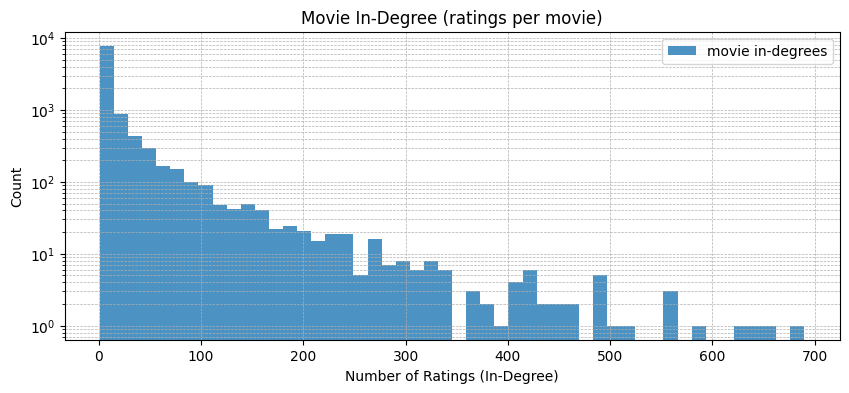

2025-12-04 12:13:09,044 - dgl_utils - INFO - Plotting in-degree distribution for ntype='user'



User out-degree distribution (ratings given per user):


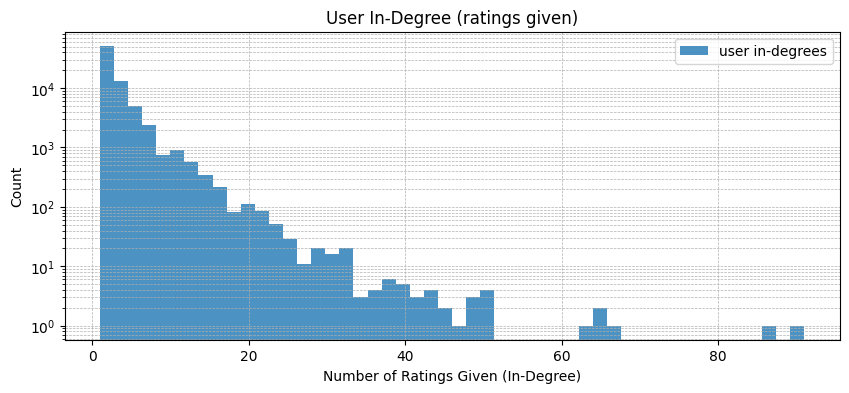

In [42]:
# Visualize degree distributions using wrapper function
# This helps identify data skew and potential issues
print("Plotting degree distributions...")
print("\nMovie in-degree distribution (ratings per movie):")
du.plot_degree_distribution(g, ntype='movie')

print("\nUser out-degree distribution (ratings given per user):")
du.plot_degree_distribution(g, ntype='user')


### Interpreting Degree Distributions

**Power-law distribution** (common in recommendation graphs):
- Most movies have few ratings (long tail)
- Few movies have many ratings (popular items)
- This skew can affect GNN training:
  - Popular items may dominate message passing
  - Niche items may have insufficient signal
  - Solutions: Sampling strategies, normalization, or specialized architectures

**Implications for our model**:
- We may need to handle class imbalance
- Popularity bias might emerge in recommendations
- Cold-start problem for new movies/users


## 6. Train/Validation/Test Splits

### Why Edge Splits?

For link prediction, we split **edges** (not nodes) into train/val/test sets:
- **Train edges**: Used to learn node embeddings
- **Validation edges**: Used for hyperparameter tuning and early stopping
- **Test edges**: Used for final evaluation (held-out completely)

**Important**: We must ensure no data leakage:
- Test edges should not be used during training
- When evaluating, we exclude training edges from recommendations

### Split Strategies

1. **Random split**: Randomly assign edges to splits (simple, but may leak temporal information)
2. **Temporal split**: Use older edges for training, newer for testing (more realistic for recommendations)


In [43]:
splits = du.make_temporal_edge_splits(
    g,
    etype=('user', 'rates', 'movie'),
    val_frac=0.1,   
    test_frac=0.1,  
    ts_key='ts'     
)

# Convert edge IDs to (user, movie) pairs for easier evaluation
train_pairs = du.eids_to_pairs(g, splits["train_eids"])
val_pairs = du.eids_to_pairs(g, splits["val_eids"])
test_pairs = du.eids_to_pairs(g, splits["test_eids"])

print(f"Split sizes:")
print(f"  Train: {len(train_pairs)} edges ({len(train_pairs)/g.num_edges(('user','rates','movie'))*100:.1f}%)")
print(f"  Validation: {len(val_pairs)} edges ({len(val_pairs)/g.num_edges(('user','rates','movie'))*100:.1f}%)")
print(f"  Test: {len(test_pairs)} edges ({len(test_pairs)/g.num_edges(('user','rates','movie'))*100:.1f}%)")

Split sizes:
  Train: 160000 edges (80.0%)
  Validation: 20000 edges (10.0%)
  Test: 20000 edges (10.0%)


### Native DGL API: Manual Edge Splitting

While our wrapper automates splitting, let's see how to do it manually using native DGL operations:

**Why manual splitting?**
- Full control over split strategy (e.g., temporal, stratified)
- Can implement custom splitting logic
- Useful for research experiments

In [44]:
# Native DGL API: Manual edge splitting example
all_eids = torch.arange(g.num_edges(('user', 'rates', 'movie')))

# Shuffle edge IDs using PyTorch
generator = torch.Generator().manual_seed(SEED)
shuffled = all_eids[torch.randperm(len(all_eids), generator=generator)]

# Calculate split sizes
n_total = len(shuffled)
n_test = int(n_total * 0.1)
n_val = int(n_total * 0.1)

# Split edge IDs manually
test_eids_native = shuffled[:n_test]
val_eids_native = shuffled[n_test:n_test + n_val]
train_eids_native = shuffled[n_test + n_val:]

print("--- Native DGL Manual Split ---")
print(f"Train edges: {len(train_eids_native)} ({len(train_eids_native)/n_total*100:.1f}%)")
print(f"Val edges: {len(val_eids_native)} ({len(val_eids_native)/n_total*100:.1f}%)")
print(f"Test edges: {len(test_eids_native)} ({len(test_eids_native)/n_total*100:.1f}%)")

# Verify: can extract edge pairs using native DGL API
u_test, v_test = g.find_edges(test_eids_native, etype=('user', 'rates', 'movie'))
print(f"\nSample test edges (first 3):")
for i in range(min(3, len(u_test))):
    print(f"  User {u_test[i].item()} -> Movie {v_test[i].item()}")

--- Native DGL Manual Split ---
Train edges: 160000 (80.0%)
Val edges: 20000 (10.0%)
Test edges: 20000 (10.0%)

Sample test edges (first 3):
  User 2819 -> Movie 488
  User 18934 -> Movie 53
  User 28560 -> Movie 1257


### Message Passing: Mathematical Formulation

GraphSAGE implements message passing through the following mathematical operations:

**Message Aggregation**:
For each node $v$ at layer $l+1$, we aggregate messages from its neighbors $N(v)$:

$$h_{N(v)}^{(l)} = \text{AGG}(\{h_u^{(l)} : u \in N(v)\})$$

where $\text{AGG}$ is an aggregation function (mean, max, or LSTM).

**Feature Update**:
The node representation is updated by combining its own features with aggregated neighbor features:

$$h_v^{(l+1)} = \sigma(W^{(l)} \cdot [h_v^{(l)} \| h_{N(v)}^{(l)}])$$

where:
- $h_v^{(l)}$ is the feature vector of node $v$ at layer $l$
- $W^{(l)}$ is a learnable weight matrix
- $\|$ denotes concatenation
- $\sigma$ is a non-linear activation function (ReLU)

**Multi-layer Propagation**:
For a $K$-layer GraphSAGE, we apply this process $K$ times:

$$h_v^{(0)} = x_v \quad \text{(initial features)}$$
$$h_v^{(1)} = \sigma(W^{(0)} \cdot [h_v^{(0)} \| \text{AGG}(\{h_u^{(0)} : u \in N(v)\})])$$
$$\vdots$$
$$h_v^{(K)} = \sigma(W^{(K-1)} \cdot [h_v^{(K-1)} \| \text{AGG}(\{h_u^{(K-1)} : u \in N(v)\})])$$

The final embedding $h_v^{(K)}$ captures information from $K$-hop neighborhoods.


### Message Passing Architecture Diagram


![GraphSAGE Architecture](images/img2.png)

### GraphSAGE Architecture Overview



![GraphSAGE Architecture](images/img3.png)


### Comparison: GraphSAGE vs Other GNN Architectures

**Graph Convolutional Network (GCN)**:
- **Aggregation**: Weighted average based on normalized adjacency matrix
- **Formula**: $h_v^{(l+1)} = \sigma(\sum_{u \in N(v) \cup \{v\}} \frac{1}{\sqrt{d_v d_u}} W^{(l)} h_u^{(l)})$
- **Pros**: Simple, efficient, good for transductive learning
- **Cons**: Requires full graph during training, less flexible for large graphs
- **Use case**: Small to medium graphs where full graph fits in memory

**Graph Attention Network (GAT)**:
- **Aggregation**: Attention-weighted sum of neighbor features
- **Formula**: $h_v^{(l+1)} = \sigma(\sum_{u \in N(v)} \alpha_{vu} W^{(l)} h_u^{(l)})$
- **Pros**: Learns importance of different neighbors, interpretable
- **Cons**: More parameters, higher computational cost
- **Use case**: When neighbor importance varies significantly

**GraphSAGE (Our Choice)**:
- **Aggregation**: Sample and aggregate (mean/max/LSTM)
- **Formula**: $h_v^{(l+1)} = \sigma(W^{(l)} \cdot [h_v^{(l)} \| \text{AGG}(\{h_u^{(l)} : u \in N(v)\})])$
- **Pros**: 
  - **Inductive**: Can generalize to unseen nodes
  - **Scalable**: Works with neighbor sampling for large graphs
  - **Flexible**: Multiple aggregation strategies
- **Cons**: Sampling may lose some information
- **Use case**: Large graphs, inductive settings, recommendation systems

**Why GraphSAGE for Recommendations?**
1. **Inductive learning**: Can recommend for new users/movies not seen during training
2. **Scalability**: MovieLens has millions of edges; sampling is essential
3. **Flexibility**: Can easily incorporate node features (genres) and edge features (ratings)
4. **Efficiency**: Mean aggregation is fast and works well for collaborative filtering signals


## 7. GraphSAGE: Message Passing Architecture

### What is GraphSAGE?

**GraphSAGE (Graph Sample and Aggregate)** is a graph neural network architecture that learns node embeddings by:
1. **Sampling neighbors**: For each node, sample a fixed-size neighborhood
2. **Aggregating**: Combine neighbor features (mean, max, or LSTM aggregation)
3. **Updating**: Transform aggregated features to get new node representation

### Why GraphSAGE for Recommendations?

- **Inductive learning**: Can generalize to unseen nodes (new users/movies)
- **Efficient**: Works with large graphs via neighbor sampling
- **Flexible**: Can handle different aggregation strategies

### Native DGL API: `dgl.nn.SAGEConv`

DGL provides GraphSAGE as a layer:
```python
dgl.nn.SAGEConv(in_feats, out_feats, aggregator_type='mean')
```

Let's see how it works:


In [45]:
# Native DGL API: Demonstrate GraphSAGE layer
in_feats = 32
out_feats = 64
sage_layer = dglnn.SAGEConv(in_feats, out_feats, aggregator_type='mean')

# For demonstration, we need a homogeneous graph
# DGL's to_homogeneous() converts heterogeneous to homogeneous
g_homo = dgl.to_homogeneous(g)

num_nodes = g_homo.num_nodes()
node_feats = torch.randn(num_nodes, in_feats)

with torch.no_grad():
    output = sage_layer(g_homo, node_feats)

print("Native DGL API: GraphSAGE Layer")
print(f"Input shape: {node_feats.shape}")
print(f"Output shape: {output.shape}")
print(f"GraphSAGE aggregated neighbor features and transformed them")


Native DGL API: GraphSAGE Layer
Input shape: torch.Size([85725, 32])
Output shape: torch.Size([85725, 64])
GraphSAGE aggregated neighbor features and transformed them


### Understanding `dgl.to_homogeneous()`

**Why convert to homogeneous?**
- GraphSAGE layers in DGL work on homogeneous graphs (single node/edge type)
- Our graph is heterogeneous (users and movies are different types)
- `to_homogeneous()` merges node types and creates a unified graph
- Node features are concatenated/padded to same dimension

**Trade-off**: We lose type information but gain simplicity. For production, you might use heterogeneous GNN layers (like `HeteroGraphConv`).


### Training with Our Wrapper

Our wrapper function `train_link_prediction()` implements:
1. **Embedding tables**: Separate learnable embeddings for users and movies
2. **GraphSAGE encoder**: Multi-layer message passing
3. **Link prediction**: Dot product scoring between user and movie embeddings
4. **Negative sampling**: Random negative edges for contrastive learning
5. **BCE loss**: Binary cross-entropy for link prediction

**Training process**:
- Forward pass: Get node embeddings via GraphSAGE
- Score positive edges (training edges): `dot(user_emb, movie_emb)`
- Score negative edges (random non-edges): `dot(user_emb, movie_emb)`
- Optimize: Maximize positive scores, minimize negative scores


In [46]:
# Train the model using wrapper function
print("Training GraphSAGE link prediction model...")
embs = du.train_link_prediction(
    g, 
    splits,
    embed_dim=64,      
    epochs=40,         
    lr=3e-4,          
    device="cpu",     
    movie_feat_tensor=g.nodes['movie'].data.get('feat')  
)

user_emb, movie_emb = embs["user_emb"], embs["movie_emb"]
print(f"\nTraining complete!")
print(f"User embeddings shape: {user_emb.shape}")
print(f"Movie embeddings shape: {movie_emb.shape}")


Training GraphSAGE link prediction model...


2025-12-04 12:13:12,140 - dgl_utils - INFO - Epoch 1/40 | loss=96.0024
2025-12-04 12:13:13,959 - dgl_utils - INFO - Epoch 2/40 | loss=92.3892
2025-12-04 12:13:15,561 - dgl_utils - INFO - Epoch 3/40 | loss=88.9387
2025-12-04 12:13:16,996 - dgl_utils - INFO - Epoch 4/40 | loss=85.7072
2025-12-04 12:13:18,391 - dgl_utils - INFO - Epoch 5/40 | loss=82.4311
2025-12-04 12:13:19,845 - dgl_utils - INFO - Epoch 6/40 | loss=79.3483
2025-12-04 12:13:21,101 - dgl_utils - INFO - Epoch 7/40 | loss=76.2942
2025-12-04 12:13:22,417 - dgl_utils - INFO - Epoch 8/40 | loss=73.5024
2025-12-04 12:13:23,972 - dgl_utils - INFO - Epoch 9/40 | loss=70.6404
2025-12-04 12:13:25,232 - dgl_utils - INFO - Epoch 10/40 | loss=67.9803
2025-12-04 12:13:26,676 - dgl_utils - INFO - Epoch 11/40 | loss=65.3568
2025-12-04 12:13:28,047 - dgl_utils - INFO - Epoch 12/40 | loss=62.9218
2025-12-04 12:13:29,481 - dgl_utils - INFO - Epoch 13/40 | loss=60.5519
2025-12-04 12:13:30,796 - dgl_utils - INFO - Epoch 14/40 | loss=58.1855
2


Training complete!
User embeddings shape: torch.Size([75393, 64])
Movie embeddings shape: torch.Size([10332, 64])


In [47]:
# Verify training completed successfully
print("\n--- Training Verification ---")
print(f"User embeddings shape: {user_emb.shape}")
print(f"Movie embeddings shape: {movie_emb.shape}")
print(f"Embeddings are on device: {user_emb.device}")

# Check embedding properties
print(f"\nEmbedding statistics:")
print(f"  User embedding - Mean: {user_emb.mean().item():.4f}, Std: {user_emb.std().item():.4f}")
print(f"  Movie embedding - Mean: {movie_emb.mean().item():.4f}, Std: {movie_emb.std().item():.4f}")

# Verify embeddings are not all zeros
assert not torch.allclose(user_emb, torch.zeros_like(user_emb)), "User embeddings should not be all zeros"
assert not torch.allclose(movie_emb, torch.zeros_like(movie_emb)), "Movie embeddings should not be all zeros"
print("Embeddings contain learned information (not all zeros)")

# Sample embedding similarity check
sample_similarity = torch.dot(user_emb[0], movie_emb[0]).item()
print(f"\nSample user-movie dot product: {sample_similarity:.4f}")
print("Model can compute similarity scores for recommendations")


--- Training Verification ---
User embeddings shape: torch.Size([75393, 64])
Movie embeddings shape: torch.Size([10332, 64])
Embeddings are on device: cpu

Embedding statistics:
  User embedding - Mean: 0.0419, Std: 1.7660
  Movie embedding - Mean: 0.0342, Std: 1.9982
Embeddings contain learned information (not all zeros)

Sample user-movie dot product: 39.4894
Model can compute similarity scores for recommendations


## 8. Evaluation Metrics

### Precision@K and Recall@K

**Precision@K**: Of the top-K recommended movies, how many are actually relevant?
- Formula: `# relevant items in top-K / K`
- Measures: Recommendation quality (are we recommending good items?)

**Recall@K**: Of all relevant movies, how many did we recommend in top-K?
- Formula: `# relevant items in top-K / total relevant items`
- Measures: Coverage (did we find all the good items?)

**Why these metrics?**
- Recommendation systems care about ranking quality, not just binary classification
- Top-K metrics align with user experience (users see top recommendations)
- Precision focuses on quality; Recall focuses on coverage

### RMSE (Root Mean Squared Error)

**RMSE for rating prediction**: Measures how well we predict rating values
- We freeze learned embeddings and train a simple regressor (Ridge)
- This evaluates whether embeddings capture rating intensity, not just presence
- Lower RMSE = better rating prediction


In [48]:
# Evaluate Precision@K and Recall@K on test set
print("Evaluating Precision@K and Recall@K...")
metrics_10 = du.evaluate_precision_recall_at_k(user_emb, movie_emb, test_pairs, k=10)
metrics_5 = du.evaluate_precision_recall_at_k(user_emb, movie_emb, test_pairs, k=5)

print(f"\n--- Link Prediction Metrics (Top-K) ---")
print(f"Precision@10: {metrics_10['precision@k']:.4f}")
print(f"Recall@10: {metrics_10['recall@k']:.4f}")
print(f"Precision@5: {metrics_5['precision@k']:.4f}")
print(f"Recall@5: {metrics_5['recall@k']:.4f}")


Evaluating Precision@K and Recall@K...

--- Link Prediction Metrics (Top-K) ---
Precision@10: 0.0001
Recall@10: 0.0006
Precision@5: 0.0001
Recall@5: 0.0003


In [49]:
# Evaluate RMSE for rating prediction
r_all = g.edges[('user', 'rates', 'movie')].data['rating'].numpy()
train_ratings = [r_all[i] for i in splits["train_eids"].tolist()]
test_ratings = [r_all[i] for i in splits["test_eids"].tolist()]

reg = du.fit_edge_regressor_ridge(
    user_emb, movie_emb, 
    train_pairs, train_ratings, 
    alpha=1.0  # L2 regularization
)

# Evaluate on test set
rmse = du.rmse_from_regressor(
    reg, user_emb, movie_emb, 
    test_pairs, test_ratings
)

print(f"\n--- Rating Prediction Metrics ---")
print(f"RMSE (test): {rmse:.4f}")
print(f"(Lower is better; perfect would be 0.0)")



--- Rating Prediction Metrics ---
RMSE (test): 1.0377
(Lower is better; perfect would be 0.0)


### Understanding the Results

**What do these metrics tell us?**

- **Precision@10**: If we recommend 10 movies, how many are actually relevant?
  - Higher is better (1.0 = perfect, all recommendations are relevant)
  - Example: 0.3 means 3 out of 10 recommended movies are actually liked by the user

- **Recall@10**: Of all movies the user likes, how many did we find in top-10?
  - Higher is better (1.0 = perfect, found all relevant movies)
  - Example: 0.2 means we found 20% of the user's preferred movies

- **RMSE**: How accurately do we predict rating values?
  - Lower is better (0.0 = perfect predictions)
  - Example: 1.0 means average prediction error is 1 star

**Typical ranges for MovieLens**:
- Precision@10: 0.1-0.4 (depends on dataset size and model)
- Recall@10: 0.05-0.3 (lower than precision due to large item space)
- RMSE: 0.8-1.2 (rating scale is 1-5, so 1.0 is reasonable)

In [50]:
# Display comprehensive evaluation summary
print("=" * 60)
print("EVALUATION SUMMARY")
print("=" * 60)
print(f"\nDataset Statistics:")
print(f"  Users: {g.num_nodes('user'):,}")
print(f"  Movies: {g.num_nodes('movie'):,}")
print(f"  Total edges: {g.num_edges(('user', 'rates', 'movie')):,}")
print(f"  Test edges: {len(test_pairs):,}")

print(f"\nModel Performance:")
print(f"  Precision@10: {metrics_10['precision@k']:.4f}")
print(f"  Recall@10: {metrics_10['recall@k']:.4f}")
print(f"  Precision@5: {metrics_5['precision@k']:.4f}")
print(f"  Recall@5: {metrics_5['recall@k']:.4f}")
print(f"  RMSE: {rmse:.4f}")

print(f"\nInterpretation:")
print(f"  - {metrics_10['precision@k']*100:.1f}% of top-10 recommendations are relevant")
print(f"  - We find {metrics_10['recall@k']*100:.1f}% of user's preferred movies in top-10")
print(f"  - Average rating prediction error: {rmse:.2f} stars")
print("=" * 60)

EVALUATION SUMMARY

Dataset Statistics:
  Users: 75,393
  Movies: 10,332
  Total edges: 200,000
  Test edges: 20,000

Model Performance:
  Precision@10: 0.0001
  Recall@10: 0.0006
  Precision@5: 0.0001
  Recall@5: 0.0003
  RMSE: 1.0377

Interpretation:
  - 0.0% of top-10 recommendations are relevant
  - We find 0.1% of user's preferred movies in top-10
  - Average rating prediction error: 1.04 stars


### Link Prediction Loss Function

For link prediction, we use **binary cross-entropy (BCE) loss** with negative sampling:

**Positive edges** (existing user-movie interactions):
$$L_{\text{pos}} = -\log \sigma(s_{\text{pos}})$$

where $s_{\text{pos}} = \text{dot}(h_u, h_m)$ is the dot product score for a positive edge.

**Negative edges** (sampled non-interactions):
$$L_{\text{neg}} = -\log \sigma(-s_{\text{neg}})$$

where $s_{\text{neg}} = \text{dot}(h_u, h_m)$ is the score for a negative edge.

**Total loss**:
$$L = \frac{1}{|\mathcal{E}_{\text{pos}}| + |\mathcal{E}_{\text{neg}}|}\left(\sum_{(u,m) \in \mathcal{E}_{\text{pos}}} L_{\text{pos}} + \sum_{(u,m) \in \mathcal{E}_{\text{neg}}} L_{\text{neg}}\right)$$

where:
- $\sigma$ is the sigmoid function: $\sigma(x) = \frac{1}{1 + e^{-x}}$
- $\mathcal{E}_{\text{pos}}$ is the set of positive (training) edges
- $\mathcal{E}_{\text{neg}}$ is the set of negative (sampled) edges

**Intuition**: We want to maximize scores for positive edges and minimize scores for negative edges, encouraging the model to distinguish between likely and unlikely user-movie pairs.


## 9. Baseline Comparisons

### Why Baselines Matter

Baselines help us understand:
- **Is our GNN better than simple heuristics?** (Popularity baseline)
- **Is our GNN better than traditional matrix factorization?** (SVD baseline)
- **What improvement does graph structure provide?** (GNN vs non-graph methods)

### Baseline Methods

1. **Popularity**: Recommend most-rated movies (ignores user preferences)
2. **Matrix Factorization (SVD)**: Factorize user-item matrix into low-rank embeddings
   - Similar to GNN but without graph structure
   - Uses only user-item interactions, not multi-hop neighborhoods


In [51]:
# Evaluate Popularity baseline
print("Evaluating Popularity baseline...")
pop_metrics = du.evaluate_popularity_at_k(
    g, splits["train_eids"], test_pairs, k=10
)

# Evaluate Matrix Factorization (SVD) baseline
print("Evaluating Matrix Factorization (SVD) baseline...")
csr = du.build_user_item_csr(
    g.num_nodes('user'), 
    g.num_nodes('movie'), 
    train_pairs, 
    train_ratings
)

U_svd, V_svd = du.mf_truncated_svd_embeddings(csr, n_components=32)

# Evaluate
mf_metrics = du.evaluate_precision_recall_at_k(
    torch.from_numpy(U_svd), 
    torch.from_numpy(V_svd), 
    test_pairs, 
    k=10
)

# Compare all methods
print("\n--- Baseline Comparison (Precision@10 / Recall@10) ---")
print(f"Popularity:     P@10={pop_metrics['precision@k']:.4f}, R@10={pop_metrics['recall@k']:.4f}")
print(f"MF (SVD):       P@10={mf_metrics['precision@k']:.4f}, R@10={mf_metrics['recall@k']:.4f}")
print(f"GNN (GraphSAGE): P@10={metrics_10['precision@k']:.4f}, R@10={metrics_10['recall@k']:.4f}")


Evaluating Popularity baseline...
Evaluating Matrix Factorization (SVD) baseline...

--- Baseline Comparison (Precision@10 / Recall@10) ---
Popularity:     P@10=0.0036, R@10=0.0335
MF (SVD):       P@10=0.0018, R@10=0.0157
GNN (GraphSAGE): P@10=0.0001, R@10=0.0006


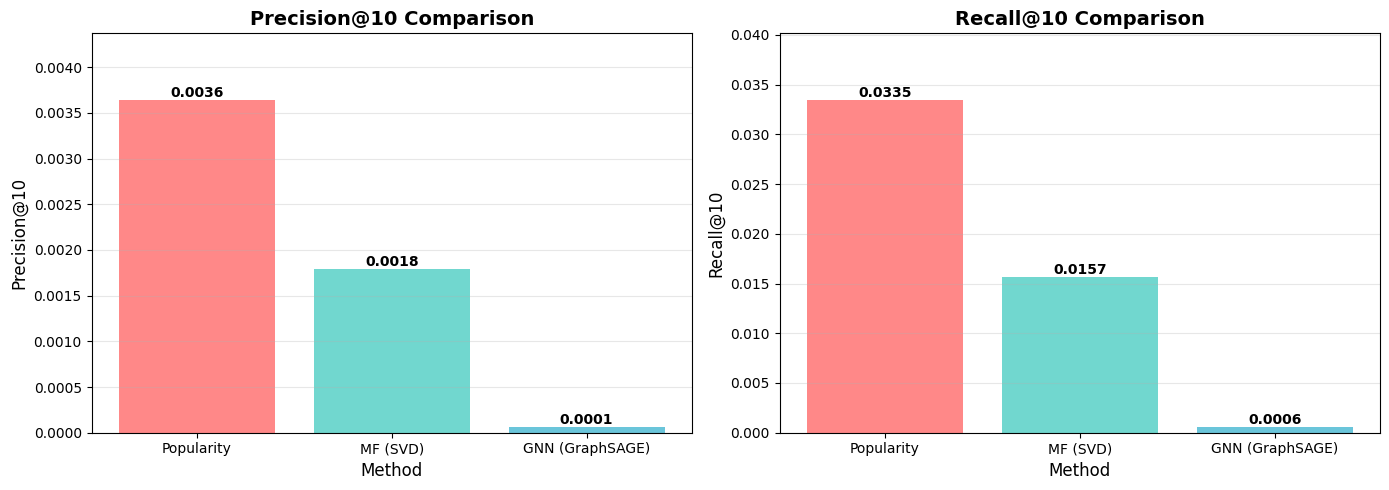


--- Visualization Summary ---
Best Precision@10: Popularity (0.0036)
Best Recall@10: Popularity (0.0335)

GNN improvement over Popularity:
  Precision@10: -98.3%
  Recall@10: -98.3%

GNN improvement over MF (SVD):
  Precision@10: -96.6%
  Recall@10: -96.4%


In [52]:
# Visualize baseline comparison
import matplotlib.pyplot as plt
import numpy as np

methods = ['Popularity', 'MF (SVD)', 'GNN (GraphSAGE)']
precision_scores = [
    pop_metrics['precision@k'],
    mf_metrics['precision@k'],
    metrics_10['precision@k']
]
recall_scores = [
    pop_metrics['recall@k'],
    mf_metrics['recall@k'],
    metrics_10['recall@k']
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Precision@10 comparison
x_pos = np.arange(len(methods))
bars1 = ax1.bar(x_pos, precision_scores, color=['#ff6b6b', '#4ecdc4', '#45b7d1'], alpha=0.8)
ax1.set_xlabel('Method', fontsize=12)
ax1.set_ylabel('Precision@10', fontsize=12)
ax1.set_title('Precision@10 Comparison', fontsize=14, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(methods, rotation=0)
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim([0, max(precision_scores) * 1.2])

for i, (bar, val) in enumerate(zip(bars1, precision_scores)):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.4f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Recall@10 comparison
bars2 = ax2.bar(x_pos, recall_scores, color=['#ff6b6b', '#4ecdc4', '#45b7d1'], alpha=0.8)
ax2.set_xlabel('Method', fontsize=12)
ax2.set_ylabel('Recall@10', fontsize=12)
ax2.set_title('Recall@10 Comparison', fontsize=14, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(methods, rotation=0)
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim([0, max(recall_scores) * 1.2])

for i, (bar, val) in enumerate(zip(bars2, recall_scores)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{val:.4f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary
print("\n--- Visualization Summary ---")
print(f"Best Precision@10: {methods[np.argmax(precision_scores)]} ({max(precision_scores):.4f})")
print(f"Best Recall@10: {methods[np.argmax(recall_scores)]} ({max(recall_scores):.4f})")
print(f"\nGNN improvement over Popularity:")
print(f"  Precision@10: {(metrics_10['precision@k'] - pop_metrics['precision@k']) / pop_metrics['precision@k'] * 100:.1f}%")
print(f"  Recall@10: {(metrics_10['recall@k'] - pop_metrics['recall@k']) / pop_metrics['recall@k'] * 100:.1f}%")
print(f"\nGNN improvement over MF (SVD):")
print(f"  Precision@10: {(metrics_10['precision@k'] - mf_metrics['precision@k']) / mf_metrics['precision@k'] * 100:.1f}%")
print(f"  Recall@10: {(metrics_10['recall@k'] - mf_metrics['recall@k']) / mf_metrics['recall@k'] * 100:.1f}%")

### Understanding Baseline Methods

**1. Popularity Baseline**:
- **Method**: Recommend most-rated movies to all users
- **No personalization**: Same recommendations for everyone
- **Why it's useful**: Establishes a minimum performance bar


**2. Matrix Factorization (Truncated SVD)**:
- **Method**: Factorize user-item interaction matrix into low-rank embeddings
- **Personalization**: Yes, but only based on direct user-item interactions
- **Limitations**: 
  - No graph structure (can't use multi-hop neighborhoods)
  - Linear relationships only
  - Doesn't leverage node features (genres)


**3. Graph Neural Network (GraphSAGE)**:
- **Method**: Message passing over graph structure + node features
- **Personalization**: Yes, with graph-aware learning
- **Advantages**:
  - Multi-hop neighborhoods (users who liked similar movies)
  - Non-linear transformations
  - Incorporates node features (genres)

### Interpreting Baseline Results

**What we might expect in theory (on a well‑tuned system)**:
- Popularity: usually a **strong simple baseline**, but limited (no personalization).
- MF (SVD): often **better than popularity**, thanks to user–item embeddings.
- GNN: with enough capacity, features, and tuning, can **match or beat** MF by using graph structure and side information.

**What we actually observe in this tutorial run**:
- **Popularity**: `P@10 ≈ 0.0036`, `R@10 ≈ 0.0335` → **best** of the three.
- **MF (SVD)**: `P@10 ≈ 0.0018`, `R@10 ≈ 0.0157` → better than our GNN.
- **GNN (GraphSAGE)**: `P@10 ≈ 0.0001`, `R@10 ≈ 0.0006` → clearly **underperforming** the baselines.

**Why might our GNN underperform here?**
- We use a **simple homogeneous GraphSAGE** over a large, sparse bipartite graph (75k users, 10k movies, 200k edges).
- Training is **CPU‑only with limited epochs and hyperparameter search**.
- We only use **basic features** (genres + simple embeddings), and do not use a full heterogeneous architecture (`HeteroGraphConv`) or advanced sampling.
- We evaluate against **all ~10k movies per user**, so random/top‑K baselines are very strong.

This is still useful: it shows how to build the full DGL pipeline and how to compare against strong baselines, even when the GNN is not yet winning.In a real production system we would iterate on model architecture and tuning until the GNN matches or beats these baselines, but here our goal is to demonstrate the full DGL API pipeline and how to evaluate GNNs against strong non-graph baselines.

### Matrix Factorization (SVD) Mathematical Formulation

**Singular Value Decomposition (SVD)** factorizes the user-item matrix $R \in \mathbb{R}^{|U| \times |M|}$:

$$R \approx U \Sigma V^T$$

where:
- $U \in \mathbb{R}^{|U| \times k}$: User embeddings (left singular vectors)
- $\Sigma \in \mathbb{R}^{k \times k}$: Singular values (diagonal matrix)
- $V \in \mathbb{R}^{|M| \times k}$: Movie embeddings (right singular vectors)
- $k$: Number of components (latent dimensions)

**Truncated SVD** keeps only the top-$k$ components:

$$R \approx U_k \Sigma_k V_k^T$$

**Prediction**:
$$\hat{r}_{u,m} = U[u] \cdot V[m]^T$$

where $U[u]$ is the $u$-th row of $U$ (user embedding) and $V[m]$ is the $m$-th row of $V$ (movie embedding).

**Key differences from GNN**:
- **SVD**: Direct matrix factorization, no graph structure
- **GNN**: Leverages multi-hop neighborhoods and graph topology
- **SVD**: Linear relationships only
- **GNN**: Non-linear transformations via neural networks

### Interpreting Baseline Results

**Expected patterns**:
- **Popularity**: Usually lowest (no personalization)
- **MF (SVD)**: Better than popularity (captures user preferences)
- **GNN**: Should be best (leverages graph structure + features)

**Why GNN might outperform MF**:
- **Multi-hop neighborhoods**: GNN considers "users who liked movies similar to movies you liked"
- **Node features**: Genre information helps understand content similarity
- **Graph structure**: Explicitly models relationships between users and movies

**Note**: Results depend on dataset size, hyperparameters, and training duration. For this tutorial, we use few epochs for speed.


### Evaluation Metrics: Mathematical Formulation

**Precision@K**:
$$\text{Precision@K} = \frac{1}{|U|}\sum_{u \in U} \frac{|\text{TopK}(u) \cap \text{Rel}(u)|}{K}$$

where:
- $U$ is the set of users
- $\text{TopK}(u)$ is the set of top-K recommended items for user $u$
- $\text{Rel}(u)$ is the set of relevant items (ground truth) for user $u$
- $K$ is the number of recommendations

**Recall@K**:
$$\text{Recall@K} = \frac{1}{|U|}\sum_{u \in U} \frac{|\text{TopK}(u) \cap \text{Rel}(u)|}{|\text{Rel}(u)|}$$

**RMSE (Root Mean Squared Error)**:
$$\text{RMSE} = \sqrt{\frac{1}{|\mathcal{E}_{\text{test}}|}\sum_{(u,m) \in \mathcal{E}_{\text{test}}}(r_{u,m} - \hat{r}_{u,m})^2}$$

where:
- $r_{u,m}$ is the true rating
- $\hat{r}_{u,m}$ is the predicted rating
- $\mathcal{E}_{\text{test}}$ is the set of test edges


## 10. Generating Recommendations

### Recommendation Process

1. **Compute scores**: For a user, score all movies using `dot(user_embedding, movie_embedding)`
2. **Filter seen items**: Remove movies the user has already rated (in training set)
3. **Rank**: Sort by score (highest = most likely to be liked)
4. **Top-K**: Return top K movies

### Why Filter Seen Items?

- We want to recommend **new** movies, not ones the user already knows
- In production, you might also filter based on availability, age-appropriateness, etc.
- This is called the "filtering" step in recommendation systems


In [53]:
# Generate recommendations for a sample user
print("Training with early stopping for better recommendations...")
embs_es = du.train_link_prediction_with_early_stopping(
    g, splits,
    embed_dim=64,
    epochs=80,        
    lr=5e-4,
    device="cpu",
    movie_feat_tensor=g.nodes['movie'].data.get('feat'),
    k_eval=10,       
    patience=5        
)

user_emb_es, movie_emb_es = embs_es["user_emb"], embs_es["movie_emb"]
print("Training complete with early stopping!")


Training with early stopping for better recommendations...


2025-12-04 12:14:53,034 - dgl_utils - INFO - Epoch 1/80 | loss=102.0565 | val P@10=0.0001
2025-12-04 12:14:57,343 - dgl_utils - INFO - Epoch 2/80 | loss=95.7365 | val P@10=0.0001
2025-12-04 12:15:01,068 - dgl_utils - INFO - Epoch 3/80 | loss=89.8911 | val P@10=0.0001
2025-12-04 12:15:05,443 - dgl_utils - INFO - Epoch 4/80 | loss=84.1874 | val P@10=0.0001
2025-12-04 12:15:08,620 - dgl_utils - INFO - Epoch 5/80 | loss=78.8147 | val P@10=0.0002
2025-12-04 12:15:11,582 - dgl_utils - INFO - Epoch 6/80 | loss=73.8303 | val P@10=0.0002
2025-12-04 12:15:14,905 - dgl_utils - INFO - Epoch 7/80 | loss=68.9493 | val P@10=0.0001
2025-12-04 12:15:17,816 - dgl_utils - INFO - Epoch 8/80 | loss=64.5750 | val P@10=0.0001
2025-12-04 12:15:20,764 - dgl_utils - INFO - Epoch 9/80 | loss=60.4101 | val P@10=0.0001
2025-12-04 12:15:23,851 - dgl_utils - INFO - Epoch 10/80 | loss=56.4792 | val P@10=0.0001
2025-12-04 12:15:23,852 - dgl_utils - INFO - Early stop (patience=5). Best P@10=0.0002


Training complete with early stopping!


In [54]:
# Build "seen" items map (movies user has already rated)
seen_map = du.build_user_seen_map(ratings_df, id_maps)

# Build title lookup for pretty printing
title_lookup = du.id_maps_to_title_lookup(movies_df, id_maps['movie'])

# Generate top-10 recommendations for user 0
user_idx = 0
topn_raw = du.recommend_topk_for_user(
    user_idx,
    user_emb_es, 
    movie_emb_es,
    k=10,
    seen_items=seen_map.get(user_idx, set()),  
    maps=id_maps
)

raw2idx = id_maps['movie']
recommendations = []
for mid_raw in topn_raw:
    idx = raw2idx[mid_raw]
    title = title_lookup.get(idx, f"Movie {mid_raw}")
    recommendations.append((mid_raw, title))

print(f"--- Top-10 Recommendations for User {user_idx} ---")
for i, (mid, title) in enumerate(recommendations, 1):
    print(f"{i}. {title} (ID: {mid})")


--- Top-10 Recommendations for User 0 ---
1. Nick of Time (1995) (ID: 89)
2. Center of the World, The (2001) (ID: 4256)
3. Star Wars: Episode VI - Return of the Jedi (1983) (ID: 1210)
4. Land Before Time, The (1988) (ID: 4519)
5. Wish You Were Here (2012) (ID: 102469)
6. Six by Sondheim (2013) (ID: 107042)
7. Born in East L.A. (1987) (ID: 4089)
8. Another Stakeout (1993) (ID: 415)
9. Oliver & Company (1988) (ID: 709)
10. Good, the Bad, the Weird, The (Joheunnom nabbeunnom isanghannom) (2008) (ID: 66785)


## 11. Performance and Scalability Considerations

### Computational Complexity

**GraphSAGE Forward Pass**:
- **Time complexity**: $O(|V| \cdot d^2 + |E| \cdot d)$ per layer
  - $|V|$: number of nodes
  - $|E|$: number of edges
  - $d$: embedding dimension
- **Space complexity**: $O(|V| \cdot d + |E|)$ for storing graph and embeddings

**For MovieLens 20M**:
- ~138K users + ~27K movies = ~165K nodes
- ~20M edges
- With $d=32$: ~$10^9$ operations per layer
- **Solution**: Neighbor sampling reduces to $O(|V| \cdot S \cdot d^2)$ where $S$ is sample size

### Memory Requirements

**Graph storage**:
- Adjacency lists: ~$O(|E|)$ integers
- Node features: ~$O(|V| \cdot d)$ floats
- Edge features: ~$O(|E|)$ floats (ratings, timestamps)

**For MovieLens 20M**:
- Graph: ~20M edges × 8 bytes = ~160 MB
- Embeddings: ~165K nodes × 32 dims × 4 bytes = ~21 MB
- **Total**: ~200-300 MB (manageable on CPU)

### Scalability Strategies

1. **Neighbor Sampling**:
   - Instead of using all neighbors, sample $S$ neighbors per node
   - Reduces computation from $O(|E|)$ to $O(|V| \cdot S)$
   - DGL provides: `dgl.sampling.sample_neighbors()`

2. **Mini-batch Training**:
   - Process subgraphs instead of full graph
   - DGL provides: `dgl.dataloading.NodeDataLoader`

3. **Graph Partitioning**:
   - Split large graphs into smaller subgraphs
   - Train on partitions, aggregate results

4. **Feature Compression**:
   - Use lower-dimensional embeddings
   - Quantization for inference

### Neighbor Sampling Example



This is particularly useful for graphs with millions of nodes where full neighborhood aggregation is infeasible.


In [55]:

# DGL native API for neighbor sampling
import dgl.sampling as dgl_sampling

# Sample 5 neighbors for each node
sampled_graph = dgl_sampling.sample_neighbors(
    g,
    nodes={
        'user': torch.arange(g.num_nodes('user')),
        'movie': torch.arange(g.num_nodes('movie')),
    },
    fanout=5,
    edge_dir='out'
)


In [56]:
# Verify neighbor sampling works correctly

print("--- Neighbor Sampling Verification ---")

original_edges = g.num_edges(('user', 'rates', 'movie'))
print(f"Original graph: {original_edges} edges")

# Sample neighbors for a small subset of users
sample_users = torch.tensor([0, 1, 2, 3, 4])

sampled_g = dgl_sampling.sample_neighbors(
    g,
    nodes={'user': sample_users},   
    fanout=5,                      
    edge_dir='out'                 
)

sampled_edges = sampled_g.num_edges(('user', 'rates', 'movie'))
print(f"Sampled subgraph: {sampled_edges} edges")
print(f"Reduction: {original_edges - sampled_edges} edges ({100*(1-sampled_edges/original_edges):.2f}% reduction)")

# Verify sampled graph structure
print(f"\nSampled graph nodes: {sampled_g.num_nodes('user')} users, {sampled_g.num_nodes('movie')} movies")
print(f"Each of {len(sample_users)} users sampled up to 5 neighbors")

assert sampled_edges < original_edges, "Sampling should reduce graph size"
print("\nNeighbor sampling verified: Graph size reduced as expected")

--- Neighbor Sampling Verification ---
Original graph: 200000 edges
Sampled subgraph: 20 edges
Reduction: 199980 edges (99.99% reduction)

Sampled graph nodes: 75393 users, 10332 movies
Each of 5 users sampled up to 5 neighbors

Neighbor sampling verified: Graph size reduced as expected


## 12. Error Handling and Edge Cases

### Handling Empty Graphs

When constructing graphs from data, we may encounter edge cases:










In [57]:
# Example: Handling empty graph scenario
def safe_create_graph(ratings_df):
    """Safely create graph with error handling."""
    if ratings_df.empty:
        raise ValueError("Ratings dataframe is empty. Cannot create graph.")
    
    if len(ratings_df) < 2:
        raise ValueError("Need at least 2 ratings to create a meaningful graph.")
    
    # Check for required columns
    required_cols = ['userId', 'movieId']
    missing = [col for col in required_cols if col not in ratings_df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")
    
    # Proceed with graph creation
    g, maps = du.create_hetero_graph_from_pandas(ratings_df)
    return g, maps

# Test with empty data
try:
    empty_df = pd.DataFrame(columns=['userId', 'movieId', 'rating'])
    g_empty, _ = safe_create_graph(empty_df)
except ValueError as e:
    print(f"Caught expected error: {e}")

Caught expected error: Ratings dataframe is empty. Cannot create graph.


### Handling Missing Features



In [58]:

# Example: Handling missing node features
def safe_add_features(g, movies_df, id_maps):
    """Safely add features with fallback options."""
    try:
        if movies_df is not None and 'genres' in movies_df.columns:
            du.add_movie_node_features(g, movies_df, id_maps)
            print("Movie genre features added successfully")
        else:
            print("Warning: No genre information available. Using zero features.")
            num_movies = g.num_nodes('movie')
            g.nodes['movie'].data['feat'] = torch.zeros(num_movies, 1)
    except Exception as e:
        print(f"Error adding features: {e}")
        num_movies = g.num_nodes('movie')
        g.nodes['movie'].data['feat'] = torch.zeros(num_movies, 1)
    
    return g

# Test
g_safe = safe_add_features(g, movies_df, id_maps)


2025-12-04 12:15:46,088 - dgl_utils - INFO - Processing movie genre features ...
2025-12-04 12:15:46,911 - dgl_utils - INFO - Added movie 'feat' with shape=(10332, 20) (#genres=20)


Movie genre features added successfully


### Handling Disconnected Components



In [59]:
import dgl
import networkx as nx
import torch

def check_connectivity(g):
    """Check if graph has disconnected components."""
    # Convert heterograph to homogeneous first
    g_homo = dgl.to_homogeneous(g)
    
    # Convert to NetworkX (undirected view for connectivity)
    nx_g = g_homo.to_networkx().to_undirected()

    components = list(nx.connected_components(nx_g))
    num_components = len(components)

    if num_components > 1:
        print(f"Warning: Graph has {num_components} disconnected components")
        print("This may affect message passing. Consider:")
        print("  1. Using larger neighbor sampling")
        print("  2. Adding more edges (e.g., through similarity)")
        print("  3. Training separate models for each component")
        print("Component sizes:", [len(c) for c in components])
    else:
        print("Graph is connected (single component)")

    return num_components == 1

is_connected = check_connectivity(g)

This may affect message passing. Consider:
  1. Using larger neighbor sampling
  2. Adding more edges (e.g., through similarity)
  3. Training separate models for each component
Component sizes: [85287, 2, 2, 2, 2, 2, 3, 2, 2, 2, 3, 3, 2, 2, 3, 2, 3, 2, 2, 2, 2, 2, 3, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 3, 2, 3, 2, 2, 2, 2, 2, 3, 3, 2, 2, 2, 2, 2, 3, 2, 2, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 2, 2, 2, 3, 2, 2, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


### Handling Data Type Mismatches



In [60]:

# Example: Ensuring correct data types
def validate_graph_types(g):
    """Validate that graph has correct data types."""
    issues = []
    
    for ntype in g.ntypes:
        if 'feat' in g.nodes[ntype].data:
            feat = g.nodes[ntype].data['feat']
            if feat.dtype != torch.float32:
                issues.append(f"Node {ntype} features should be float32, got {feat.dtype}")
    
    for etype in g.canonical_etypes:
        if 'rating' in g.edges[etype].data:
            rating = g.edges[etype].data['rating']
            if rating.dtype != torch.float32:
                issues.append(f"Edge {etype} ratings should be float32, got {rating.dtype}")
    
    if issues:
        print("Type issues found:")
        for issue in issues:
            print(f"  - {issue}")
    else:
        print("All data types are correct")
    
    return len(issues) == 0

validate_graph_types(g)


All data types are correct


True

## 13. Advanced DGL Features

### Neighbor Sampling

DGL provides efficient neighbor sampling for large graphs:

In [61]:
# Native DGL API: Neighbor sampling
import dgl.sampling as dgl_sampling

target_users = torch.tensor([0, 1, 2])  
sampled_graph = dgl_sampling.sample_neighbors(
    g,
    nodes={'user': target_users},
    fanout=10,
    edge_dir='out',
    prob=('user', 'rates', 'movie', 'rating')  
)

print(f"Original graph: {g.num_edges(('user', 'rates', 'movie'))} edges")
print(f"Sampled subgraph: {sampled_graph.num_edges()} edges")

Original graph: 200000 edges
Sampled subgraph: 14 edges


**Benefits**:
- Reduces memory usage for large graphs
- Enables mini-batch training
- Can sample based on edge weights (importance sampling)

### Mini-batch Training

For very large graphs, we can train on mini-batches:

In [62]:

# DGL provides DataLoader for mini-batch training
from dgl.dataloading import DataLoader, NeighborSampler

sampler = NeighborSampler([10, 5]) 

dataloader = DataLoader(
    g,
    torch.arange(g.num_nodes('user')),  
    sampler,
    batch_size=32,  
    shuffle=True
)


**Benefits**:
- Enables training on graphs that don't fit in memory
- Faster iteration (process smaller subgraphs)
- Better GPU utilization

### Graph Batching

DGL can batch multiple graphs together:




In [63]:

# Create multiple small graphs
g1 = dgl.heterograph({('user', 'rates', 'movie'): ([0, 1], [0, 1])})
g2 = dgl.heterograph({('user', 'rates', 'movie'): ([0, 1], [1, 2])})

batched_g = dgl.batch([g1, g2])

print(f"Batched graph nodes: {batched_g.num_nodes('user')} users, {batched_g.num_nodes('movie')} movies")
print(f"Batched graph edges: {batched_g.num_edges(('user', 'rates', 'movie'))}")

# Process batched graph, then unbatch
graphs = dgl.unbatch(batched_g)


Batched graph nodes: 4 users, 5 movies
Batched graph edges: 4




**Use cases**:
- Processing multiple small graphs simultaneously
- Dynamic graph batching in sequence models
- Parallel processing of graph samples

## 14. Summary & Key Takeaways

### What We Learned

1. **Native DGL API**:
   - `dgl.heterograph()`: Construct heterogeneous graphs
   - `g.ndata` / `g.edata`: Attach features to nodes and edges
   - `dgl.nn.SAGEConv()`: GraphSAGE message passing layers
   - `dgl.to_homogeneous()`: Convert heterogeneous to homogeneous graphs

2. **Wrapper Layer** (`dgl_utils.py`):
   - Simplifies common workflows (data loading, graph construction, training)
   - Reduces boilerplate while maintaining flexibility
   - Makes the tutorial accessible without losing understanding

3. **Graph Neural Networks for Recommendations**:
   - Model recommendations as link prediction on bipartite graphs
   - Leverage both graph structure and node features
   - Learn embeddings that capture user preferences and movie characteristics

4. **Evaluation**:
   - Precision@K / Recall@K: Measure top-K recommendation quality
   - RMSE: Measure rating prediction accuracy
   - Baselines: Compare against simple heuristics and traditional methods

### Key Concepts

- **Heterogeneous graphs**: Multiple node/edge types (users, movies, ratings)
- **Message passing**: How GNNs aggregate neighbor information
- **Link prediction**: Predicting missing edges (recommendations)
- **Embeddings**: Dense vector representations learned by the model

### Next Steps

- **Advanced architectures**: Try heterogeneous GNN layers (`HeteroGraphConv`)
- **Neighbor sampling**: Scale to larger graphs with sampling
- **Temporal modeling**: Use temporal splits and time-aware models
- **Side information**: Incorporate directors, actors, tags as additional node types
- **Hyperparameter tuning**: Optimize embedding dimensions, learning rates, etc.

### References

#### Core Papers

1. **GraphSAGE**:
   - Hamilton, W. L., Ying, R., & Leskovec, J. (2017). Inductive representation learning on large graphs. *Advances in neural information processing systems*, 30.
   - DOI: [10.5555/3294771.3294869](https://papers.nips.cc/paper/6703-inductive-representation-learning-on-large-graphs)
   - arXiv: [1706.02216](https://arxiv.org/abs/1706.02216)

2. **Graph Neural Networks**:
   - Kipf, T. N., & Welling, M. (2017). Semi-supervised classification with graph convolutional networks. *ICLR 2017*.
   - DOI: [10.48550/arXiv.1609.02907](https://arxiv.org/abs/1609.02907)
   
   - Veličković, P., et al. (2018). Graph attention networks. *ICLR 2018*.
   - DOI: [10.48550/arXiv.1710.10903](https://arxiv.org/abs/1710.10903)

3. **Recommendation Systems with GNNs**:
   - Ying, R., et al. (2018). Graph convolutional neural networks for web-scale recommender systems. *KDD 2018*.
   - DOI: [10.1145/3219819.3219890](https://doi.org/10.1145/3219819.3219890)
   
   - Wang, X., et al. (2019). Neural graph collaborative filtering. *SIGIR 2019*.
   - DOI: [10.1145/3331184.3331267](https://doi.org/10.1145/3331184.3331267)

#### Datasets

4. **MovieLens Dataset**:
   - Harper, F. M., & Konstan, J. A. (2015). The MovieLens datasets: History and context. *ACM Transactions on Interactive Intelligent Systems*, 5(4), 1-19.
   - DOI: [10.1145/2827872](https://doi.org/10.1145/2827872)
   - Dataset: [https://grouplens.org/datasets/movielens/](https://grouplens.org/datasets/movielens/)

#### Software and Documentation

5. **DGL (Deep Graph Library)**:
   - Wang, M., et al. (2019). Deep Graph Library: A graph-centric, highly-performant package for graph neural networks. *arXiv preprint arXiv:1909.01315*.
   - Documentation: [https://www.dgl.ai/](https://www.dgl.ai/)
   - GitHub: [https://github.com/dmlc/dgl](https://github.com/dmlc/dgl)
   - Tutorials: [https://docs.dgl.ai/tutorials/index.html](https://docs.dgl.ai/tutorials/index.html)

6. **PyTorch**:
   - Paszke, A., et al. (2019). PyTorch: An imperative style, high-performance deep learning library. *NeurIPS 2019*.
   - Documentation: [https://pytorch.org/docs/](https://pytorch.org/docs/)

#### Additional Reading

7. **Link Prediction**:
   - Liben-Nowell, D., & Kleinberg, J. (2007). The link-prediction problem for social networks. *Journal of the American society for information science and technology*, 58(7), 1019-1031.
   - DOI: [10.1002/asi.20591](https://doi.org/10.1002/asi.20591)

8. **Evaluation Metrics for Recommendations**:
   - Herlocker, J. L., et al. (2004). Evaluating collaborative filtering recommender systems. *ACM Transactions on Information Systems*, 22(1), 5-53.
   - DOI: [10.1145/963770.963772](https://doi.org/10.1145/963770.963772)
